# Gold Volatility Prediction with an LSTM

Forecasting gold's realised volatility 5 and 22 trading days ahead from 30-day
sequences of HAR components, macro and cross-asset features, and implied
volatility.

This notebook follows `xgboost_gold_prediction.ipynb` section for section, so the
two models are judged on the same sample, the same splits, the same benchmarks,
and the same metrics. The network itself is carried over from our earlier
return-prediction notebook unchanged: a 30-day lookback, one LSTM layer followed
by dropout and a single linear unit, Adam on mean squared error, standardised
features and target, early stopping on validation loss, and the same five
candidate configurations compared on validation loss alone.

Self-contained: run top to bottom. Figures are saved to `report_figures/` with an
`lstm_` prefix so they sit alongside the XGBoost figures rather than overwrite
them. Runtime is roughly 1.5 hours on CPU, almost all of it model fitting.

## 1. Setup and Data Loading

In [1]:
import os
import random
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # keep the training logs readable
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

DATA_PATH = "daily_commodity_market_data_cleaned.csv"
FIG_DIR = "report_figures"
RESULTS_DIR = "results"

# CBOE GVZ inception; also drops the 2004-2007 gold range data, which is
# unusable (38-55% of days report High == Low)
START_DATE = "2008-06-03"

TEST_FRACTION = 0.20
SEED = 42

# Network and training settings, unchanged from the return-prediction notebook
LOOKBACK = 30            # trading days of history in each input sequence
VALIDATION_FRACTION = 0.15   # tail of the training window, held out for early stopping
MAX_EPOCHS = 100
PATIENCE = 10

HAR_FEATURES = ["har_daily", "har_weekly", "har_monthly"]

MACRO_FEATURES = [
    "gold_return_1d", "gold_return_5d", "gold_return_20d",
    "gold_volatility_5d", "gold_volatility_20d", "gold_close_pos",
    "gold_volume_change", "gold_relative_volume",
    "crude_oil_return_1d", "silver_return_1d", "copper_return_1d",
    "platinum_return_1d", "us_dollar_index_return_1d", "sp_500_return_1d",
    "eur_usd_return_1d", "vix_change_1d", "breakeven_inflation_10y_diff_bps",
    "us_2_year_treasury_yields_diff_bps", "us_10_year_treasury_yields_diff_bps",
    "two_ten_slope", "two_ten_slope_change_bps",
]

# The only forward-looking block in the feature set
IMPLIED_FEATURES = ["gvz_log", "gvz_change", "gvz_5d", "vrp", "ovx_log"]

ALL_FEATURES = HAR_FEATURES + MACRO_FEATURES + IMPLIED_FEATURES

# The baseline architecture from the return notebook, reused unchanged
BASELINE_PARAMS = {"lstm_units": 64, "dropout_rate": 0.2,
                   "learning_rate": 0.001, "batch_size": 32}

# The same five candidates the return notebook searched. A controlled manual
# grid rather than a random search: each LSTM fit costs minutes, where the
# XGBoost notebook could afford 40 randomised configurations.
TUNING_CONFIGS = [
    {"config_id": 1, "lstm_units": 16, "dropout_rate": 0.2, "learning_rate": 0.001,  "batch_size": 32},
    {"config_id": 2, "lstm_units": 32, "dropout_rate": 0.2, "learning_rate": 0.001,  "batch_size": 32},
    {"config_id": 3, "lstm_units": 32, "dropout_rate": 0.3, "learning_rate": 0.001,  "batch_size": 32},
    {"config_id": 4, "lstm_units": 32, "dropout_rate": 0.4, "learning_rate": 0.0005, "batch_size": 32},
    {"config_id": 5, "lstm_units": 64, "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 64},
]

# The ablations retune every row, so they search a shortlist
ABLATION_CONFIGS = TUNING_CONFIGS[:3]

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
pd.set_option("display.width", 200)


def reset_seeds():
    """Keras initialises stochastically; reset before every fit so configs stay comparable."""
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)


reset_seeds()


def show(name):
    """Save the current figure for the report, then display it."""
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print("TensorFlow", tf.__version__)
print("Devices:", tf.config.list_physical_devices())
print(f"{len(ALL_FEATURES)} features: {len(HAR_FEATURES)} HAR, "
      f"{len(MACRO_FEATURES)} macro, {len(IMPLIED_FEATURES)} implied volatility")

TensorFlow 2.21.0


Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
29 features: 3 HAR, 21 macro, 5 implied volatility


Volatility metrics: QLIKE, the Diebold-Mariano test, and the smearing
correction. Copied unchanged from the XGBoost notebook so both models are scored
by exactly the same code.

In [2]:
def qlike_loss(y_true, y_pred):
    """Per-observation QLIKE on variance. Zero for a perfect forecast."""
    ratio = y_true ** 2 / y_pred ** 2
    return ratio - np.log(ratio) - 1


def diebold_mariano(loss_a, loss_b, horizon):
    """Test whether model A's loss differs from model B's. Negative favours A."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    n = len(d)
    d_bar = d.mean()
    dc = d - d_bar
    # Newey-West: overlapping forecast windows autocorrelate the differentials
    var = (dc @ dc) / n
    for lag in range(1, max(horizon, 1)):
        if lag >= n:
            break
        var += 2 * (1 - lag / horizon) * ((dc[lag:] @ dc[:-lag]) / n)
    if var <= 0:
        return np.nan, np.nan
    stat = d_bar / np.sqrt(var / n)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))


def smearing(train_residuals):
    """Duan's retransformation factor, from training residuals only.

    Exponentiating a log-scale fit returns the conditional median, not the
    mean, so the level-scale forecast comes out biased low.
    """
    return float(np.log(np.mean(np.exp(np.asarray(train_residuals)))))


def score(name, y_true_log, y_pred_log, reference_log, horizon):
    """Metrics on the log scale (what is fitted) and the level scale."""
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.asarray(y_pred_log, dtype=float)
    y_true, y_pred = np.exp(y_true_log), np.exp(y_pred_log)
    reference = np.exp(np.asarray(reference_log, dtype=float))
    return {
        "Model": name,
        "Horizon": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "R2_level": r2_score(y_true, y_pred),
        "QLIKE": qlike_loss(y_true, y_pred).mean(),
        "Directional_Accuracy": np.mean((y_true > reference) == (y_pred > reference)),
    }

In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
full_history = data.copy()
data = data.loc[START_DATE:]

print(f"Cleaned file:     {full_history.index.min().date()} to {full_history.index.max().date()}  "
      f"({len(full_history)} rows)")
print(f"Volatility model: {data.index.min().date()} to {data.index.max().date()}  ({len(data)} rows)")

Cleaned file:     2004-01-22 to 2026-07-30  (5029 rows)


Volatility model: 2008-06-27 to 2026-07-30  (4309 rows)


Sample starts 2008-06-03: GVZ inception, and the 2004-2007 gold range data is
unusable (38-55% of days report `High == Low`). The return notebook trained on
the full history; a volatility model cannot.

## 2. Chronological Splits with a Purge Gap

Same 80/20 chronological split and the same `h`-day purge as the XGBoost
notebook: training stops `h` days before the test set, because the target
averages the next `h` days and those labels are not known yet.

Two details the sequence model adds. An example at row `i` spans rows
`i - 29 .. i`, so the first `LOOKBACK - 1` rows can only ever serve as history,
never as a training example. And test sequences reach back across the split for
their history, which is fine -- those rows are inputs, all observable at
prediction time -- while every test *label* stays behind the purge gap.

Because of that reach-back the split is kept as row positions rather than
sub-frames. It is the same idea as the `create_boundary_sequences` helper in the
return notebook, just expressed once instead of twice.

In [4]:
def make_split(frame, features, target, reference, horizon):
    """Chronological 80/20 split, training stopped `horizon` days early.

    Returns the usable frame plus the row positions that can act as training and
    test examples. Positions rather than sub-frames, because every example also
    needs the LOOKBACK-1 rows sitting in front of it.
    """
    usable = frame.dropna(subset=list(features) + [target, reference])
    cut = int(len(usable) * (1 - TEST_FRACTION))
    train_pos = np.arange(LOOKBACK - 1, cut - horizon)
    test_pos = np.arange(cut, len(usable))
    return usable, train_pos, test_pos


splits = {}
for h in (5, 22):
    splits[h] = make_split(data, ALL_FEATURES, f"vol_target_{h}d", f"vol_current_{h}d", h)

pd.DataFrame([
    {"Horizon": h,
     "Train rows": len(tr), "Train starts": u.index[tr[0]].date(), "Train ends": u.index[tr[-1]].date(),
     "Test rows": len(te), "Test starts": u.index[te[0]].date(), "Test ends": u.index[te[-1]].date()}
    for h, (u, tr, te) in splits.items()
])

,Horizon,Train rows,Train starts,Train ends,Test rows,Test starts,Test ends
0,5,3194,2008-10-16,2023-03-06,807,2023-03-14,2026-07-24
1,22,3169,2008-10-16,2023-01-13,805,2023-02-17,2026-06-30


## 3. Benchmarks: Persistence and HAR

The same two references the XGBoost notebook uses, fitted on exactly the rows
the LSTM trains on so the comparison is like for like. Both are fitted on log
volatility, so exponentiating returns the median rather than the mean; Duan's
smearing factor corrects it, applied to HAR as well as to the network.

In [5]:
def fit_har(usable, train_pos, test_pos, target, har_features):
    """HAR benchmark with the retransformation bias corrected."""
    train, test = usable.iloc[train_pos], usable.iloc[test_pos]
    model = LinearRegression().fit(train[har_features], train[target])
    bias = smearing(train[target] - model.predict(train[har_features]))
    return model.predict(test[har_features]) + bias


h = 5
usable, train_pos, test_pos = splits[h]
target, reference = f"vol_target_{h}d", f"vol_current_{h}d"
test = usable.iloc[test_pos]

results = []
results.append(score("Persistence", test[target], test[reference], test[reference], h))
har_pred = fit_har(usable, train_pos, test_pos, target, HAR_FEATURES)
results.append(score("HAR (linear)", test[target], har_pred, test[reference], h))

train = usable.iloc[train_pos]
bias = smearing(train[target] - LinearRegression().fit(
    train[HAR_FEATURES], train[target]).predict(train[HAR_FEATURES]))
print(f"Smearing factor for HAR: {np.exp(bias):.4f}  "
      f"(level forecasts were {100 * (np.exp(bias) - 1):.1f}% too low)")
pd.DataFrame(results)

Smearing factor for HAR: 1.0696  (level forecasts were 7.0% too low)


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002766,0.004637,0.357742,0.287009,0.398164,0.650558


## 4. Baseline LSTM

The architecture and the training loop come straight from the return notebook:
`LSTM(units) -> Dropout -> Dense(1)`, Adam on mean squared error, sequences fed
in chronological order (`shuffle=False`), and early stopping on validation loss
with `restore_best_weights`. The baseline is its baseline -- 64 units, dropout
0.2, learning rate 0.001, batch size 32.

Three things are specific to the volatility target:

- **Scaling.** Features and target are standardised on the training window only.
  The return notebook did the same; XGBoost needed neither.
- **Validation slice.** Early stopping needs one, so the last 15% of the
  training window is held out and purged by `h` days from the rows still being
  fitted. The return notebook carved this out as a separate 70/15/15 split; here
  it comes out of the 80% training block so the test set matches XGBoost's
  exactly.
- **Smearing.** Predictions are inverse-transformed back to log volatility, then
  the training-residual smearing factor is added before exponentiating.

In [6]:
def create_sequences(matrix, positions):
    """Stack the LOOKBACK rows ending at each position into (n, LOOKBACK, n_features).

    Replaces the create_training_sequences / create_boundary_sequences pair from
    the return notebook: indexing by position handles the split boundary on its
    own, since a sequence simply reaches back into whatever rows precede it.
    """
    idx = positions[:, None] - np.arange(LOOKBACK - 1, -1, -1)[None, :]
    return matrix[idx]


def build_lstm_model(n_features, params, activation=None, loss="mean_squared_error"):
    """The return notebook's build_lstm_model, with the output layer parameterised."""
    model = Sequential([
        Input(shape=(LOOKBACK, n_features)),
        LSTM(params["lstm_units"]),
        Dropout(params["dropout_rate"]),
        Dense(1, activation=activation),
    ])
    model.compile(optimizer=Adam(learning_rate=params["learning_rate"]), loss=loss)
    return model


def fit_lstm(usable, features, target, fit_pos, eval_pos, params, horizon,
             apply_smearing=True, verbose=0):
    """Train on `fit_pos`, predict `eval_pos`, and return log-scale predictions.

    The tail of the fitting window becomes the early-stopping validation slice,
    purged by `horizon` days so its labels do not overlap the rows still being
    fitted. Scalers see the fitting window only.
    """
    n_validation = max(int(len(fit_pos) * VALIDATION_FRACTION), LOOKBACK)
    split_at = len(fit_pos) - n_validation - horizon
    if split_at < LOOKBACK:
        raise ValueError("fitting window too short for a validation slice")
    inner_train, inner_validation = fit_pos[:split_at], fit_pos[-n_validation:]

    feature_scaler = StandardScaler().fit(usable[features].to_numpy()[:fit_pos[-1] + 1])
    target_scaler = StandardScaler().fit(usable[[target]].to_numpy()[fit_pos])
    X_all = feature_scaler.transform(usable[features].to_numpy()).astype("float32")
    y_all = target_scaler.transform(usable[[target]].to_numpy()).astype("float32").ravel()

    reset_seeds()
    model = build_lstm_model(len(features), params)
    history = model.fit(
        create_sequences(X_all, inner_train), y_all[inner_train],
        validation_data=(create_sequences(X_all, inner_validation), y_all[inner_validation]),
        epochs=MAX_EPOCHS,
        batch_size=params["batch_size"],
        shuffle=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                 restore_best_weights=True)],
        verbose=verbose,
    )

    def predict_from(matrix, positions):
        """Predictions on the log-volatility scale, before the smearing correction."""
        scaled = model.predict(create_sequences(matrix, positions), verbose=0)
        return target_scaler.inverse_transform(scaled).ravel()

    bias = 0.0
    if apply_smearing:
        bias = smearing(usable[target].to_numpy()[fit_pos] - predict_from(X_all, fit_pos))

    info = {
        "model": model, "history": history, "params": params, "bias": bias,
        "X_all": X_all, "predict_from": predict_from,
        "best_validation_loss": float(np.min(history.history["val_loss"])),
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "epochs_trained": len(history.history["loss"]),
    }
    return info, (None if eval_pos is None else predict_from(X_all, eval_pos) + bias)

In [7]:
baseline_info, baseline_pred = fit_lstm(
    usable, ALL_FEATURES, target, train_pos, test_pos, BASELINE_PARAMS, h, verbose=1)

print(f"\nStopped after {baseline_info['epochs_trained']} epochs, "
      f"best epoch {baseline_info['best_epoch']}, "
      f"validation loss {baseline_info['best_validation_loss']:.6f}")
print(f"Smearing factor for the baseline LSTM: {np.exp(baseline_info['bias']):.4f}")

results.append(score("LSTM (default)", test[target], baseline_pred, test[reference], h))
pd.DataFrame(results)

Epoch 1/100


 1/85 ━━━━━━━━━━━━━━━━━━━━ 6:22 5s/step - loss: 6.4266

 4/85 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.0059

 7/85 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.2174

10/85 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.7445

...

78/85 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2729

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2733

85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2761 - val_loss: 0.7754



Stopped after 13 epochs, best epoch 3, validation loss 0.539325
Smearing factor for the baseline LSTM: 1.0655


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002766,0.004637,0.357742,0.287009,0.398164,0.650558
2,LSTM (default),5,0.002475,0.004326,0.474405,0.379556,0.312864,0.712515


### 4.1 Training and validation loss

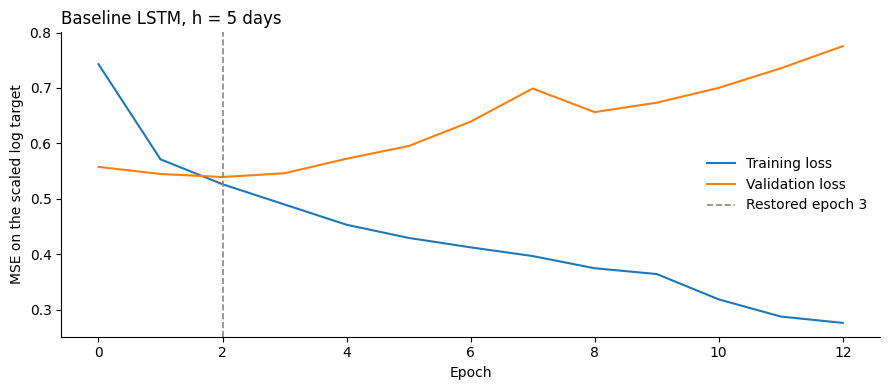

In [8]:
plt.figure(figsize=(9, 4))
plt.plot(baseline_info["history"].history["loss"], label="Training loss")
plt.plot(baseline_info["history"].history["val_loss"], label="Validation loss")
plt.axvline(baseline_info["best_epoch"] - 1, color="#898781", ls="--", lw=1.2,
            label=f"Restored epoch {baseline_info['best_epoch']}")
plt.xlabel("Epoch")
plt.ylabel("MSE on the scaled log target")
plt.title("Baseline LSTM, h = 5 days", loc="left")
plt.legend(frameon=False)
plt.gca().spines[["top", "right"]].set_visible(False)
show("lstm_training_curve")

## 5. Hyperparameter Tuning

The return notebook's approach, unchanged: a small controlled grid over LSTM
units, dropout, learning rate, and batch size, with candidates ranked on
**validation loss only** so the test set stays untouched until the winner is
picked. The lookback stays at 30 for every candidate, so they all see the same
inputs.

This is where the notebook departs from XGBoost's protocol, and it is a cost
decision rather than a preference. XGBoost scored 40 configurations by
expanding-window cross-validation with `gap=h`; at roughly a minute per LSTM
fit, the same search would take most of a day. The single purged validation
slice is the cheaper substitute, and it is the same slice early stopping already
uses.

Results are cached by feature set, target, and horizon, because section 6
retunes both horizons and would otherwise repeat the search.

In [9]:
_TUNE_CACHE = {}


def tune(usable, features, target, horizon, train_pos, configs=TUNING_CONFIGS):
    """Fit each candidate and rank on validation loss. Never touches the test set."""
    key = (tuple(features), target, horizon, len(train_pos), len(configs))
    if key in _TUNE_CACHE:
        return _TUNE_CACHE[key]

    rows = []
    for config in configs:
        params = {k: v for k, v in config.items() if k != "config_id"}
        info, _ = fit_lstm(usable, features, target, train_pos, None, params, horizon,
                           apply_smearing=False)
        rows.append({**config,
                     "best_epoch": info["best_epoch"],
                     "epochs_trained": info["epochs_trained"],
                     "best_validation_loss": info["best_validation_loss"]})
        print(f"  config {config['config_id']}: units={config['lstm_units']:>2} "
              f"dropout={config['dropout_rate']} lr={config['learning_rate']} "
              f"batch={config['batch_size']} -> val loss {info['best_validation_loss']:.6f}")

    log = pd.DataFrame(rows).sort_values("best_validation_loss").reset_index(drop=True)
    best = {k: log.iloc[0][k] for k in ("lstm_units", "dropout_rate", "learning_rate", "batch_size")}
    best = {"lstm_units": int(best["lstm_units"]), "dropout_rate": float(best["dropout_rate"]),
            "learning_rate": float(best["learning_rate"]), "batch_size": int(best["batch_size"])}
    _TUNE_CACHE[key] = (best, log)
    return _TUNE_CACHE[key]


print(f"Searching {len(TUNING_CONFIGS)} configurations at h = {h}")
best_params, tuning_log = tune(usable, ALL_FEATURES, target, h, train_pos)
print("\nBest configuration:")
for key, value in sorted(best_params.items()):
    print(f"  {key:<16} {value}")
tuning_log

Searching 5 configurations at h = 5


  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.494907


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.524760


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.524883


  config 4: units=32 dropout=0.4 lr=0.0005 batch=32 -> val loss 0.515494


  config 5: units=64 dropout=0.3 lr=0.0005 batch=64 -> val loss 0.533057

Best configuration:
  batch_size       32
  dropout_rate     0.2
  learning_rate    0.001
  lstm_units       16


,config_id,lstm_units,dropout_rate,learning_rate,batch_size,best_epoch,epochs_trained,best_validation_loss
0,1,16,0.2,0.0010,32,10,20,0.494907
1,4,32,0.4,0.0005,32,17,27,0.515494
2,2,32,0.2,0.0010,32,6,16,0.524760
3,3,32,0.3,0.0010,32,7,17,0.524883
4,5,64,0.3,0.0005,64,8,18,0.533057


In [10]:
tuned_info, tuned_pred = fit_lstm(
    usable, ALL_FEATURES, target, train_pos, test_pos, best_params, h, verbose=1)

results.append(score("LSTM (tuned)", test[target], tuned_pred, test[reference], h))
pd.DataFrame(results)

Epoch 1/100


 1/85 ━━━━━━━━━━━━━━━━━━━━ 6:07 4s/step - loss: 12.0595

 3/85 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.2055 

 5/85 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 6.9813

 7/85 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 6.1390

...

76/85 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4383

80/85 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4366

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4349

85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.3979 - val_loss: 0.5322


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002766,0.004637,0.357742,0.287009,0.398164,0.650558
2,LSTM (default),5,0.002475,0.004326,0.474405,0.379556,0.312864,0.712515
3,LSTM (tuned),5,0.002513,0.004450,0.464002,0.343479,0.347059,0.695167


## 6. Tuned Model Evaluation

QLIKE is the primary metric. R^2 is reported on the log scale (what is fitted)
and the level scale (dominated by a few high-volatility days).

In [11]:
def evaluate_horizon(horizon):
    u, tr, te_pos = splits[horizon]
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    te = u.iloc[te_pos]
    rows, preds = [], {}

    rows.append(score("Persistence", te[tgt], te[ref], te[ref], horizon))
    preds["Persistence"] = np.exp(te[ref].to_numpy())

    hp = fit_har(u, tr, te_pos, tgt, HAR_FEATURES)
    rows.append(score("HAR (linear)", te[tgt], hp, te[ref], horizon))
    preds["HAR (linear)"] = np.exp(hp)

    _, dp = fit_lstm(u, ALL_FEATURES, tgt, tr, te_pos, BASELINE_PARAMS, horizon)
    rows.append(score("LSTM (default)", te[tgt], dp, te[ref], horizon))
    preds["LSTM (default)"] = np.exp(dp)

    print(f"Tuning at h = {horizon}")
    bp, _ = tune(u, ALL_FEATURES, tgt, horizon, tr)
    info, tp = fit_lstm(u, ALL_FEATURES, tgt, tr, te_pos, bp, horizon)
    rows.append(score("LSTM (tuned)", te[tgt], tp, te[ref], horizon))
    preds["LSTM (tuned)"] = np.exp(tp)

    return pd.DataFrame(rows), preds, info, te, tgt


metrics_5, preds_5, info_5, test_5, target_5 = evaluate_horizon(5)
metrics_22, preds_22, info_22, test_22, target_22 = evaluate_horizon(22)
all_metrics = pd.concat([metrics_5, metrics_22], ignore_index=True)
all_metrics

Tuning at h = 5


Tuning at h = 22


  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.302182


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.311829


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.309217


  config 4: units=32 dropout=0.4 lr=0.0005 batch=32 -> val loss 0.312793


  config 5: units=64 dropout=0.3 lr=0.0005 batch=64 -> val loss 0.305900


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002766,0.004637,0.357742,0.287009,0.398164,0.650558
2,LSTM (default),5,0.002475,0.004326,0.474405,0.379556,0.312864,0.712515
3,LSTM (tuned),5,0.002513,0.004450,0.464002,0.343479,0.347059,0.695167
4,Persistence,22,0.002886,0.004028,0.151586,0.049466,0.370000,0.541615
5,HAR (linear),22,0.002384,0.003487,0.344493,0.287665,0.291893,0.638509
6,LSTM (default),22,0.002053,0.003244,0.483832,0.383495,0.237372,0.709317
7,LSTM (tuned),22,0.002074,0.003259,0.470507,0.377547,0.251600,0.725466


### 6.1 Actual versus predicted

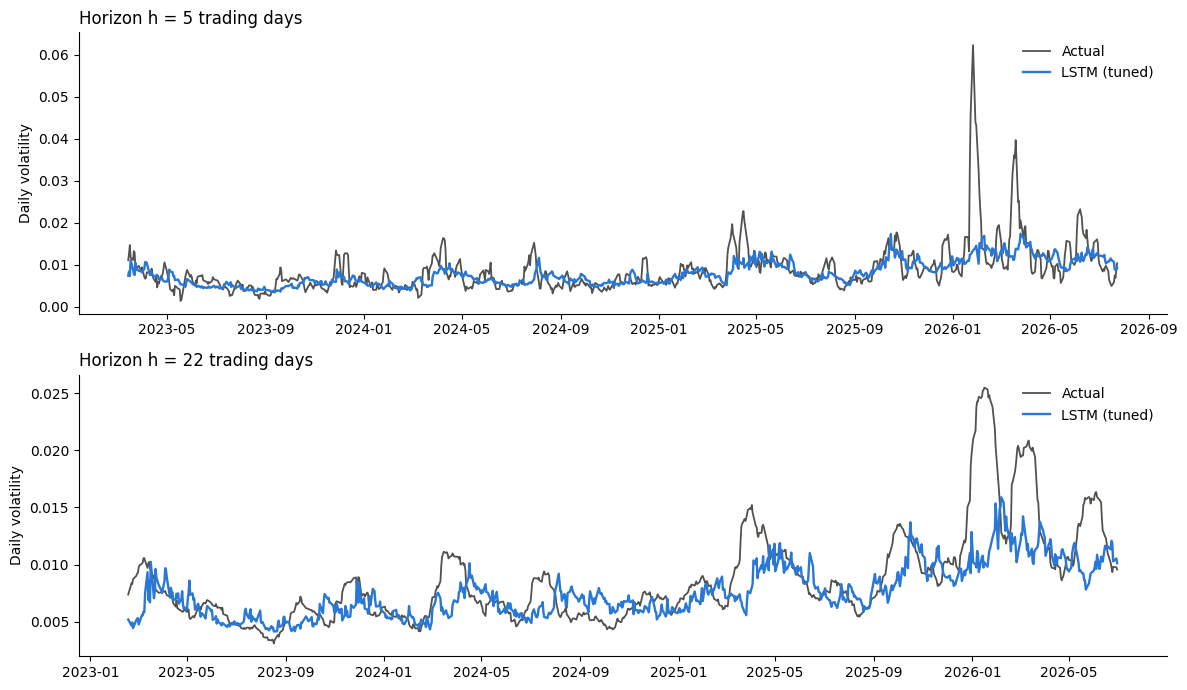

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (te, tgt, preds, hh) in zip(axes, [(test_5, target_5, preds_5, 5),
                                           (test_22, target_22, preds_22, 22)]):
    ax.plot(te.index, np.exp(te[tgt]), color="#52514e", lw=1.3, label="Actual")
    ax.plot(te.index, preds["LSTM (tuned)"], color="#2a78d6", lw=1.7, label="LSTM (tuned)")
    ax.set_title(f"Horizon h = {hh} trading days", loc="left")
    ax.set_ylabel("Daily volatility")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
show("lstm_actual_vs_predicted")

### 6.2 Residuals

Carried over from the return notebook. On a log target the residual is a
proportional error, so a residual of 0.2 means the forecast was about 20% low.
Structure here -- drift, or errors that fan out in one regime -- is what would
tell us the network is mis-specified rather than just noisy.

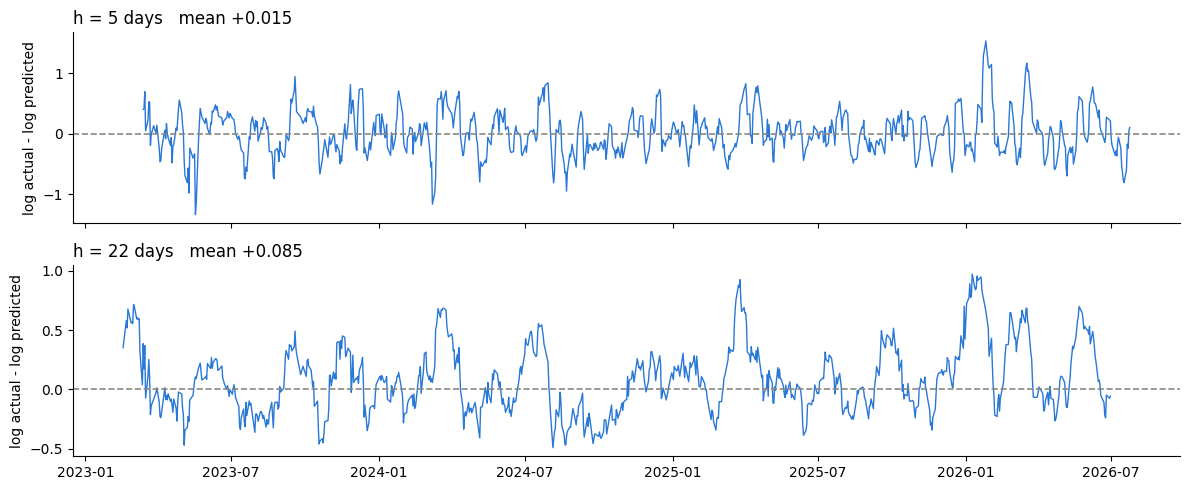

count      mean       std       min       25%       50%       75%       max
5  Actual        807.0  0.008659  0.005495  0.001405  0.005340  0.007259  0.010261  0.062307
   Predicted     807.0  0.007938  0.002868  0.003553  0.005667  0.007289  0.009897  0.017437
   Residual_log  807.0  0.014713  0.362399 -1.336417 -0.224266 -0.008497  0.228316  1.535525
22 Actual        805.0  0.008713  0.004134  0.003097  0.005855  0.007466  0.010309  0.025481
   Predicted     805.0  0.007622  0.002282  0.004137  0.005846  0.007082  0.009209  0.015887
   Residual_log  805.0  0.085490  0.286110 -0.489862 -0.117083  0.055251  0.258213  0.970978

In [13]:
residual_frames = {}
for hh, te, tgt, preds in ((5, test_5, target_5, preds_5), (22, test_22, target_22, preds_22)):
    residual_frames[hh] = pd.DataFrame({
        "Actual": np.exp(te[tgt].to_numpy()),
        "Predicted": preds["LSTM (tuned)"],
        "Residual_log": te[tgt].to_numpy() - np.log(preds["LSTM (tuned)"]),
    }, index=te.index)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, hh in zip(axes, (5, 22)):
    ax.plot(residual_frames[hh].index, residual_frames[hh]["Residual_log"],
            color="#2a78d6", lw=1)
    ax.axhline(0, color="#898781", ls="--", lw=1.2)
    ax.set_title(f"h = {hh} days   mean {residual_frames[hh]['Residual_log'].mean():+.3f}", loc="left")
    ax.set_ylabel("log actual - log predicted")
    ax.spines[["top", "right"]].set_visible(False)
show("lstm_residuals")

pd.concat({hh: residual_frames[hh].describe().T for hh in (5, 22)})

## 7. Statistical Significance (Diebold-Mariano)

Newey-West with `h-1` lags, because overlapping forecast windows autocorrelate
the loss differentials.

In [14]:
def dm_table(preds, te, tgt, horizon):
    actual = np.exp(te[tgt].to_numpy())
    model_loss = qlike_loss(actual, preds["LSTM (tuned)"])
    rows = []
    for name in ("Persistence", "HAR (linear)", "LSTM (default)"):
        stat, pval = diebold_mariano(model_loss, qlike_loss(actual, preds[name]), horizon)
        rows.append({"Horizon": horizon, "Comparison": f"LSTM (tuned) vs {name}",
                     "DM_statistic": stat, "p_value": pval,
                     "Significant_5pct": bool(pval < 0.05)})
    return pd.DataFrame(rows)


dm_all = pd.concat([dm_table(preds_5, test_5, target_5, 5),
                    dm_table(preds_22, test_22, target_22, 22)], ignore_index=True)
dm_all

,Horizon,Comparison,DM_statistic,p_value,Significant_5pct
0,5,LSTM (tuned) vs Persistence,-2.845634,0.004432,True
1,5,LSTM (tuned) vs HAR (linear),-2.175651,0.029581,True
2,5,LSTM (tuned) vs LSTM (default),1.809035,0.070446,False
3,22,LSTM (tuned) vs Persistence,-3.179890,0.001473,True
4,22,LSTM (tuned) vs HAR (linear),-1.587189,0.112470,False
5,22,LSTM (tuned) vs LSTM (default),0.958290,0.337916,False


### 7.1 Model comparison

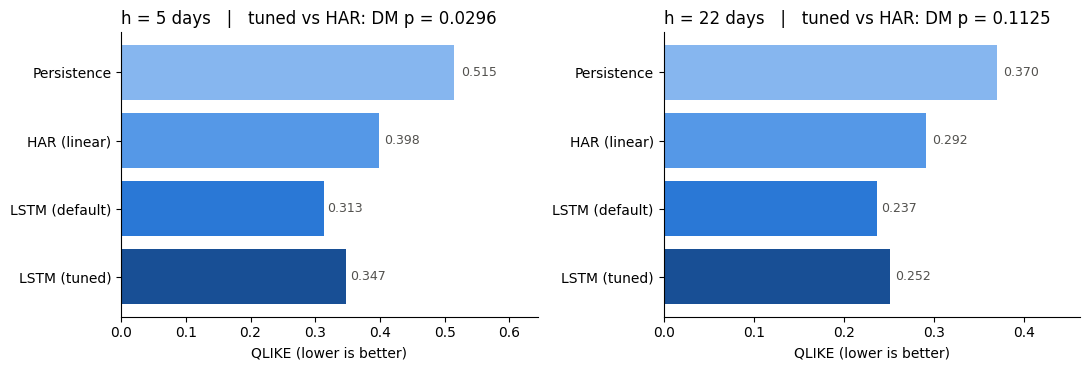

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, hh in zip(axes, (5, 22)):
    sub = all_metrics[all_metrics["Horizon"] == hh]
    p = dm_all[(dm_all.Horizon == hh) &
               (dm_all.Comparison == "LSTM (tuned) vs HAR (linear)")]["p_value"].iloc[0]
    ax.barh(sub["Model"], sub["QLIKE"],
            color=["#86b6ef", "#5598e7", "#2a78d6", "#184f95"])
    for y, v in enumerate(sub["QLIKE"]):
        ax.text(v * 1.02, y, f"{v:.3f}", va="center", fontsize=9, color="#52514e")
    ax.invert_yaxis()
    ax.set_xlim(0, sub["QLIKE"].max() * 1.25)
    ax.set_xlabel("QLIKE (lower is better)")
    ax.set_title(f"h = {hh} days   |   tuned vs HAR: DM p = {p:.4f}", loc="left")
    ax.spines[["top", "right"]].set_visible(False)
show("lstm_model_comparison")

## 8. Feature Importance

An LSTM has no split-gain importance, so this is **permutation importance**:
shuffle one feature across every timestep of the test sequences, re-predict, and
record how much QLIKE gets worse. Averaged over three shuffles.

It answers a slightly different question from XGBoost's gain -- how much the
fitted network *relies* on a feature at prediction time, rather than how useful
that feature was while trees were being grown -- so the two rankings are related
but not interchangeable.

Unshuffled QLIKE: 0.3471


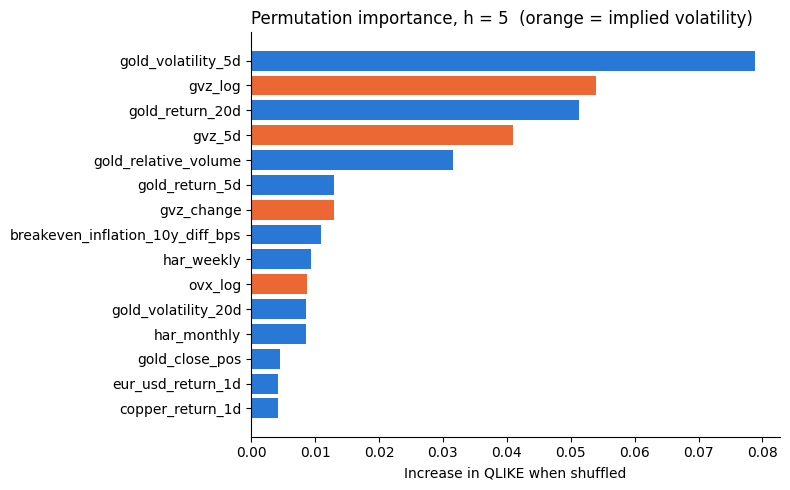

,Feature,Importance
0,gold_volatility_5d,0.078802
1,gvz_log,0.053912
2,gold_return_20d,0.051290
3,gvz_5d,0.041031
4,gold_relative_volume,0.031563
5,gold_return_5d,0.013013
6,gvz_change,0.012922
7,breakeven_inflation_10y_diff_bps,0.010868
8,har_weekly,0.009447
9,ovx_log,0.008732


In [16]:
N_PERMUTATIONS = 3


def permutation_importance(info, usable, features, target, positions, n_repeats=N_PERMUTATIONS):
    actual = np.exp(usable[target].to_numpy()[positions])
    base = np.exp(info["predict_from"](info["X_all"], positions) + info["bias"])
    baseline_loss = qlike_loss(actual, base).mean()

    rng = np.random.default_rng(SEED)
    rows = []
    for j, name in enumerate(features):
        losses = []
        for _ in range(n_repeats):
            shuffled = info["X_all"].copy()
            shuffled[:, j] = rng.permutation(shuffled[:, j])
            pred = np.exp(info["predict_from"](shuffled, positions) + info["bias"])
            losses.append(qlike_loss(actual, pred).mean())
        rows.append({"Feature": name, "Importance": float(np.mean(losses) - baseline_loss)})
    return (pd.DataFrame(rows).sort_values("Importance", ascending=False)
            .reset_index(drop=True), baseline_loss)


usable_5, _, test_pos_5 = splits[5]
importance, baseline_qlike = permutation_importance(
    info_5, usable_5, ALL_FEATURES, target_5, test_pos_5)
print(f"Unshuffled QLIKE: {baseline_qlike:.4f}")

top = importance.head(15).iloc[::-1]
colors = ["#eb6834" if f in IMPLIED_FEATURES else "#2a78d6" for f in top["Feature"]]
plt.figure(figsize=(8, 5))
plt.barh(top["Feature"], top["Importance"], color=colors)
plt.xlabel("Increase in QLIKE when shuffled")
plt.title("Permutation importance, h = 5  (orange = implied volatility)", loc="left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("lstm_feature_importance")
importance.head(10)

## 9. Ablations

### 9.1 Volatility estimator: Yang-Zhang versus Parkinson

R^2 is not comparable across the two rows because the target differs; the
Diebold-Mariano column is the valid comparison. Both rows retune, over the
three-configuration shortlist.

In [17]:
estimator_rows = []
for label, prefix in (("Yang-Zhang (overnight gap + intraday)", ""),
                      ("Parkinson (intraday range only)", "park_")):
    har_cols = [prefix + f for f in HAR_FEATURES]
    features = har_cols + MACRO_FEATURES + IMPLIED_FEATURES
    tgt, ref = f"{prefix}vol_target_5d", f"{prefix}vol_current_5d"
    u, tr, te_pos = make_split(data, features, tgt, ref, 5)
    te = u.iloc[te_pos]

    print(label)
    bp, _ = tune(u, features, tgt, 5, tr, configs=ABLATION_CONFIGS)
    _, pred = fit_lstm(u, features, tgt, tr, te_pos, bp, 5)
    row = score(label, te[tgt], pred, te[ref], 5)

    hp = fit_har(u, tr, te_pos, tgt, har_cols)
    actual = np.exp(te[tgt].to_numpy())
    stat, pval = diebold_mariano(qlike_loss(actual, np.exp(pred)),
                                 qlike_loss(actual, np.exp(hp)), 5)
    row.update({"DM_vs_HAR": stat, "DM_p_value": pval})
    estimator_rows.append(row)

estimator_ablation = pd.DataFrame(estimator_rows).drop(columns=["Model"])
estimator_ablation.insert(0, "Estimator", [r["Model"] for r in estimator_rows])
estimator_ablation

Yang-Zhang (overnight gap + intraday)


  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.494907


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.524760


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.524883


Parkinson (intraday range only)


  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.570830


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.564131


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.567930


,Estimator,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy,DM_vs_HAR,DM_p_value
0,Yang-Zhang (overnight gap + intraday),5,0.002513,0.004450,0.464002,0.343479,0.347059,0.695167,-2.175651,0.029581
1,Parkinson (intraday range only),5,0.002335,0.004048,0.367963,0.300646,0.402072,0.656753,-1.251271,0.210836


### 9.2 Feature set

In [18]:
feature_sets = {
    "HAR only": HAR_FEATURES,
    "Macro / cross-asset only": MACRO_FEATURES,
    "HAR + macro (original set)": HAR_FEATURES + MACRO_FEATURES,
    "HAR + implied volatility": HAR_FEATURES + IMPLIED_FEATURES,
    "HAR + macro + implied (full)": ALL_FEATURES,
}

# One common row set, so the comparison is over features and nothing else
common = data.dropna(subset=ALL_FEATURES + ["vol_target_5d", "vol_current_5d"])
cut = int(len(common) * (1 - TEST_FRACTION))
tr_c = np.arange(LOOKBACK - 1, cut - 5)
te_c = np.arange(cut, len(common))
test_common = common.iloc[te_c]

rows = []
for label, feats in feature_sets.items():
    print(label)
    bp, _ = tune(common, feats, "vol_target_5d", 5, tr_c, configs=ABLATION_CONFIGS)
    _, pred = fit_lstm(common, feats, "vol_target_5d", tr_c, te_c, bp, 5)
    row = score(label, test_common["vol_target_5d"], pred, test_common["vol_current_5d"], 5)
    row["N_features"] = len(feats)
    rows.append(row)

feature_ablation = pd.DataFrame(rows).rename(columns={"Model": "Feature_set"})
feature_ablation[["Feature_set", "N_features", "R2_log", "R2_level", "QLIKE"]]

HAR only


  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.542111


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.545873


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.541503


Macro / cross-asset only


...

  config 1: units=16 dropout=0.2 lr=0.001 batch=32 -> val loss 0.505870


  config 2: units=32 dropout=0.2 lr=0.001 batch=32 -> val loss 0.523344


  config 3: units=32 dropout=0.3 lr=0.001 batch=32 -> val loss 0.524208


HAR + macro + implied (full)


,Feature_set,N_features,R2_log,R2_level,QLIKE
0,HAR only,3,0.367504,0.269028,0.401307
1,Macro / cross-asset only,21,0.392410,0.261749,0.413048
2,HAR + macro (original set),24,0.410392,0.266746,0.415549
3,HAR + implied volatility,8,0.351655,0.257966,0.424991
4,HAR + macro + implied (full),29,0.464002,0.343479,0.347059


### 9.3 Both ablations

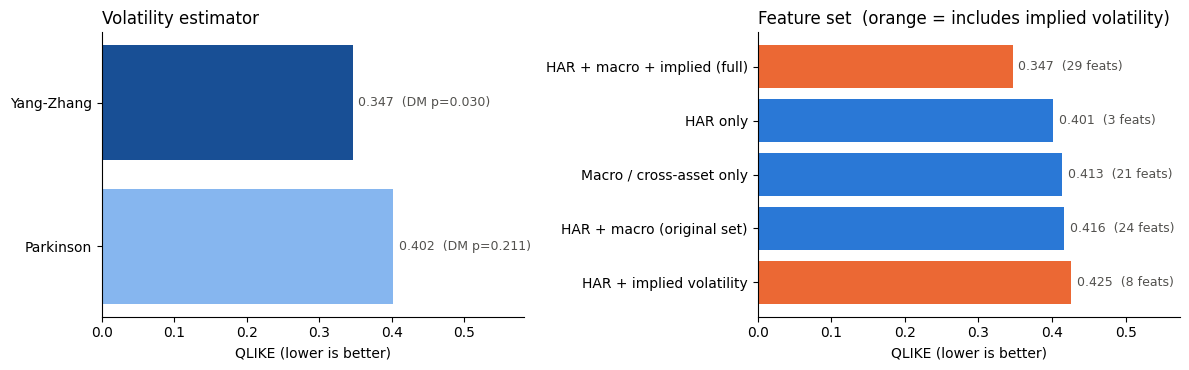

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

est = estimator_ablation.iloc[::-1]
axes[0].barh(est["Estimator"].str.replace(r" \(.*", "", regex=True), est["QLIKE"],
             color=["#86b6ef", "#184f95"])
for y, (v, p) in enumerate(zip(est["QLIKE"], est["DM_p_value"])):
    axes[0].text(v * 1.02, y, f"{v:.3f}  (DM p={p:.3f})", va="center",
                 fontsize=9, color="#52514e")
axes[0].set_xlim(0, est["QLIKE"].max() * 1.45)
axes[0].set_title("Volatility estimator", loc="left")

feat = feature_ablation.sort_values("QLIKE", ascending=False)
axes[1].barh(feat["Feature_set"], feat["QLIKE"],
             color=["#eb6834" if "implied" in f else "#2a78d6" for f in feat["Feature_set"]])
for y, (v, n) in enumerate(zip(feat["QLIKE"], feat["N_features"])):
    axes[1].text(v * 1.02, y, f"{v:.3f}  ({n} feats)", va="center",
                 fontsize=9, color="#52514e")
axes[1].set_xlim(0, feat["QLIKE"].max() * 1.35)
axes[1].set_title("Feature set  (orange = includes implied volatility)", loc="left")

for ax in axes:
    ax.set_xlabel("QLIKE (lower is better)")
    ax.spines[["top", "right"]].set_visible(False)
show("lstm_ablations")

## 10. Volatility-Direction Classifier

Binary framing of the same problem, which supports ROC-AUC and a confusion
matrix. Same network, with a sigmoid output unit and binary cross-entropy in
place of the linear unit and MSE.

In [20]:
CLASSIFIER_PARAMS = {"lstm_units": 32, "dropout_rate": 0.3,
                     "learning_rate": 0.0005, "batch_size": 64}


def run_classifier(horizon):
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    frame = data.dropna(subset=ALL_FEATURES + [tgt, ref]).copy()
    frame["label"] = (frame[tgt] > frame[ref]).astype("float32")
    cut = int(len(frame) * (1 - TEST_FRACTION))
    tr = np.arange(LOOKBACK - 1, cut - horizon)
    te = np.arange(cut, len(frame))

    n_validation = int(len(tr) * VALIDATION_FRACTION)
    inner_train, inner_validation = tr[:-(n_validation + horizon)], tr[-n_validation:]

    feature_scaler = StandardScaler().fit(frame[ALL_FEATURES].to_numpy()[:tr[-1] + 1])
    X_all = feature_scaler.transform(frame[ALL_FEATURES].to_numpy()).astype("float32")
    labels = frame["label"].to_numpy()

    reset_seeds()
    clf = build_lstm_model(len(ALL_FEATURES), CLASSIFIER_PARAMS,
                           activation="sigmoid", loss="binary_crossentropy")
    clf.fit(create_sequences(X_all, inner_train), labels[inner_train],
            validation_data=(create_sequences(X_all, inner_validation), labels[inner_validation]),
            epochs=MAX_EPOCHS, batch_size=CLASSIFIER_PARAMS["batch_size"], shuffle=False,
            callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                     restore_best_weights=True)],
            verbose=0)

    y_true = labels[te].astype(int)
    proba = clf.predict(create_sequences(X_all, te), verbose=0).ravel()
    y_pred = (proba >= 0.5).astype(int)
    metrics = {
        "Horizon": horizon,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Majority_Baseline": max(y_true.mean(), 1 - y_true.mean()),
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "F1": f1_score(y_true, y_pred),
        "N_test": len(te),
    }
    return metrics, y_true, proba, y_pred


clf_rows, roc_data = [], {}
for hh in (5, 22):
    m, y_true, proba, y_pred = run_classifier(hh)
    clf_rows.append(m)
    roc_data[hh] = (y_true, proba, y_pred)
clf_metrics = pd.DataFrame(clf_rows)
clf_metrics

,Horizon,Accuracy,Majority_Baseline,ROC_AUC,PR_AUC,F1,N_test
0,5,0.660471,0.503098,0.724801,0.753002,0.645078,807
1,22,0.703106,0.541615,0.796332,0.747797,0.582897,805


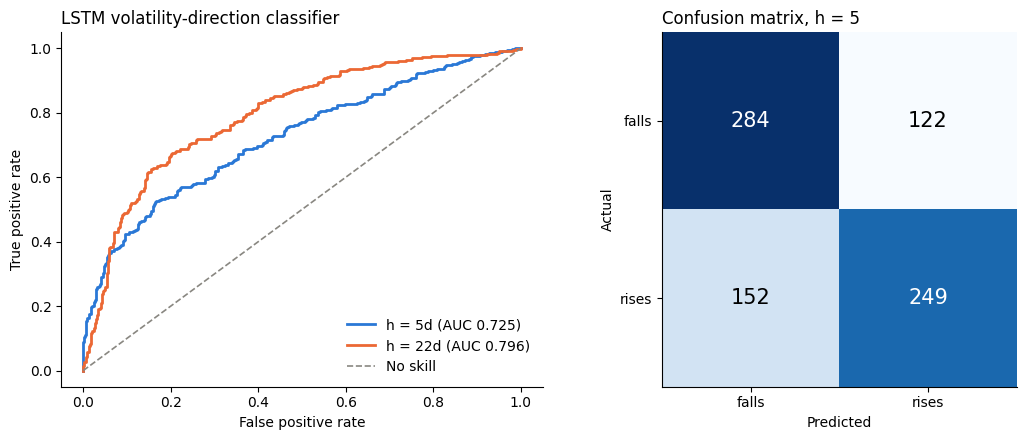

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for hh, color in ((5, "#2a78d6"), (22, "#eb6834")):
    y_true, proba, _ = roc_data[hh]
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"h = {hh}d (AUC {roc_auc_score(y_true, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#898781", lw=1.2, label="No skill")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("LSTM volatility-direction classifier", loc="left")
axes[0].legend(frameon=False)

y_true, _, y_pred = roc_data[5]
cm = confusion_matrix(y_true, y_pred)
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1], ["falls", "rises"]); axes[1].set_yticks([0, 1], ["falls", "rises"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix, h = 5", loc="left")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                     color="white" if cm[i, j] > cm.max() * 0.6 else "black")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
show("lstm_direction_roc")

## 11. One-Year Walk-Forward Backtest

Train only on data from before the last year, then walk forward, refitting on
everything that has already resolved. Scored against a 20-day trailing average,
which costs nothing.

One deviation from the XGBoost notebook, forced by cost: XGBoost refits every
single day of the window, which is 236 fits. At roughly a minute each that is
not practical for an LSTM, so the network is refitted every 21 trading days
(about monthly) and the most recent fit forecasts the days in between. The
model's information set is therefore slightly staler than XGBoost's -- up to a
month rather than a day -- but never leakier.

In [22]:
BACKTEST_START = "2025-07-31"
REFIT_EVERY = 21           # trading days between refits
BT_PARAMS = {"lstm_units": 32, "dropout_rate": 0.2,
             "learning_rate": 0.001, "batch_size": 64}

bt = data.copy()
bt["y1"] = bt["har_daily"].shift(-1)                  # next-day log volatility
bt["realised"] = np.exp(bt["y1"])
bt["naive"] = bt["gold_return_1d"].rolling(20).std()  # free comparator
bt["gold_next"] = np.expm1(bt["tomorrow_gold_log_return"])
bt = bt.dropna(subset=ALL_FEATURES + ["y1", "gold_next", "naive"])

start_pos = int(bt.index.searchsorted(pd.Timestamp(BACKTEST_START)))
print(f"Train on      {bt.index[0].date()} to {bt.index[start_pos - 1].date()}  ({start_pos} rows)")
print(f"Walk forward  {bt.index[start_pos].date()} to {bt.index[-1].date()}  "
      f"({len(bt) - start_pos} rows, refitting every {REFIT_EVERY})")

records = []
for block_start in range(start_pos, len(bt), REFIT_EVERY):
    block = np.arange(block_start, min(block_start + REFIT_EVERY, len(bt)))
    # Stop one row short: the label at block_start-1 is the volatility of
    # block_start, which is exactly what this block is being asked to forecast
    history = np.arange(LOOKBACK - 1, block_start - 1)
    _, pred_log = fit_lstm(bt, ALL_FEATURES, "y1", history, block, BT_PARAMS, 1)
    rows = bt.iloc[block]
    records.append(pd.DataFrame({
        "forecast": np.exp(pred_log),
        "naive": rows["naive"].to_numpy(),
        "realised": rows["realised"].to_numpy(),
        "gold_next": rows["gold_next"].to_numpy(),
    }, index=rows.index))
    print(f"  refit at {bt.index[block_start].date()}: forecast {len(block)} days")

wf = pd.concat(records)
wf.index.name = "Date"
print()
print(f"Forecast R2 on log volatility: "
      f"{r2_score(np.log(wf.realised), np.log(wf.forecast)):+.3f}")
print(f"Model RMSE {np.sqrt(np.mean((wf.realised - wf.forecast) ** 2)):.5f}  "
      f"vs naive 20d {np.sqrt(np.mean((wf.realised - wf.naive) ** 2)):.5f}")

Train on      2008-07-28 to 2025-07-30  (3633 rows)
Walk forward  2025-07-31 to 2026-07-29  (237 rows, refitting every 21)


  refit at 2025-07-31: forecast 21 days


  refit at 2025-08-29: forecast 21 days


  refit at 2025-10-02: forecast 21 days


  refit at 2025-11-04: forecast 21 days


...

  refit at 2026-03-16: forecast 21 days


  refit at 2026-04-17: forecast 21 days


  refit at 2026-05-18: forecast 21 days


  refit at 2026-06-17: forecast 21 days


  refit at 2026-07-22: forecast 6 days

Forecast R2 on log volatility: +0.130
Model RMSE 0.00946  vs naive 20d 0.01127


### 11.1 Trading the forecast from a $1,000 stake

The forecast cannot pick direction -- returns are not predictable -- but it can
*size* a position: hold more gold when volatility is forecast to be low,
targeting a constant 10% annualised risk. Net of 2bp costs on turnover.

The naive line applies the identical rule to a 20-day trailing average, which
costs nothing. The gap between it and the model line is what the forecast
contributes; the gap to buy-and-hold is mostly the sizing rule itself.

In [23]:
STAKE = 1000.0
COST = 0.0002              # 2 bps of traded notional
TARGET_ANNUAL_VOL = 0.10   # size the position to a constant 10% annual risk
MAX_LEVERAGE = 3.0

equity = pd.DataFrame(index=wf.index)
equity["Gold buy & hold"] = STAKE * (1 + wf["gold_next"]).cumprod()

for label, vol in (("Vol-targeted gold (naive 20d)", wf["naive"]),
                   ("Vol-targeted gold (LSTM)", wf["forecast"])):
    weight = (TARGET_ANNUAL_VOL / np.sqrt(252) / vol).clip(0, MAX_LEVERAGE)
    turnover = np.abs(np.diff(np.r_[0.0, weight]))
    equity[label] = STAKE * (1 + weight * wf["gold_next"] - turnover * COST).cumprod()

summary = pd.DataFrame([{
    "Strategy": name,
    "Final $": curve.iloc[-1],
    "Profit $": curve.iloc[-1] - STAKE,
    "Return %": 100 * (curve.iloc[-1] / STAKE - 1),
    "Sharpe": np.sqrt(252) * curve.pct_change().mean() / curve.pct_change().std(),
    "Max DD %": 100 * (curve / curve.cummax() - 1).min(),
} for name, curve in equity.items()])
summary

,Strategy,Final $,Profit $,Return %,Sharpe,Max DD %
0,Gold buy & hold,1097.082939,97.082939,9.708294,0.430403,-27.466656
1,Vol-targeted gold (naive 20d),1091.246872,91.246872,9.124687,0.697769,-14.906707
2,Vol-targeted gold (LSTM),1155.302353,155.302353,15.530235,0.902810,-18.225202


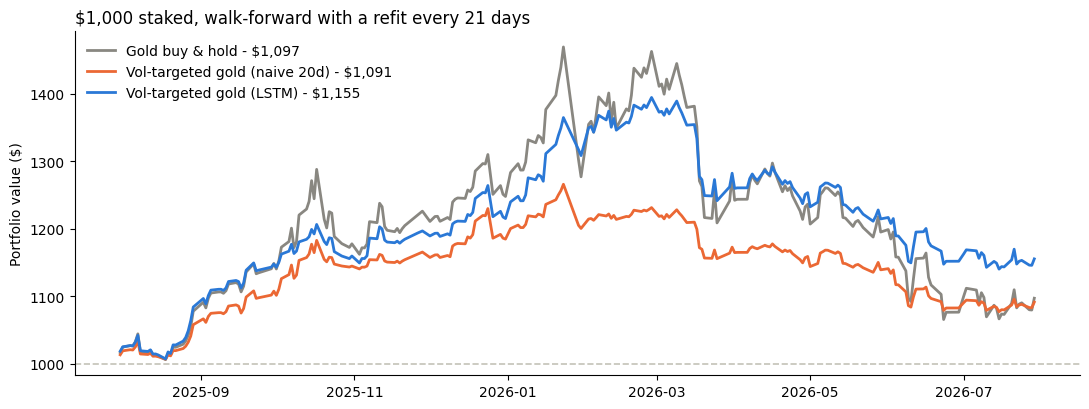

In [24]:
series = [("Gold buy & hold", "#898781"),
          ("Vol-targeted gold (naive 20d)", "#eb6834"),
          ("Vol-targeted gold (LSTM)", "#2a78d6")]

plt.figure(figsize=(11, 4.2))
for name, color in series:
    plt.plot(equity.index, equity[name], color=color, lw=2,
             label=f"{name} - ${equity[name].iloc[-1]:,.0f}")
plt.axhline(STAKE, color="#c3c2b7", ls="--", lw=1.2)
plt.ylabel("Portfolio value ($)")
plt.title(f"$1,000 staked, walk-forward with a refit every {REFIT_EVERY} days", loc="left")
plt.legend(frameon=False, loc="upper left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("lstm_backtest_equity")

## 12. Export Results

Written under an `lstm_vol_` prefix. The old `lstm_metrics.csv` and
`lstm_predictions.csv` belong to the return model and are left in place.

In [25]:
from pathlib import Path

out = Path(RESULTS_DIR)

all_metrics.to_csv(out / "lstm_vol_metrics.csv", index=False)
dm_all.to_csv(out / "lstm_vol_dm_tests.csv", index=False)
tuning_log.to_csv(out / "lstm_vol_tuning_results.csv", index=False)
importance.to_csv(out / "lstm_vol_feature_importance.csv", index=False)
feature_ablation.to_csv(out / "lstm_vol_feature_ablation.csv", index=False)
estimator_ablation.to_csv(out / "lstm_vol_estimator_ablation.csv", index=False)
clf_metrics.to_csv(out / "lstm_vol_direction_metrics.csv", index=False)
summary.to_csv(out / "lstm_vol_backtest_summary.csv", index=False)

predictions_export = pd.concat([
    pd.DataFrame({"Date": test_5.index, "Horizon": 5,
                  "Actual_Volatility": np.exp(test_5[target_5].to_numpy()),
                  "Persistence": preds_5["Persistence"],
                  "HAR": preds_5["HAR (linear)"],
                  "LSTM_Default": preds_5["LSTM (default)"],
                  "LSTM_Tuned": preds_5["LSTM (tuned)"]}),
    pd.DataFrame({"Date": test_22.index, "Horizon": 22,
                  "Actual_Volatility": np.exp(test_22[target_22].to_numpy()),
                  "Persistence": preds_22["Persistence"],
                  "HAR": preds_22["HAR (linear)"],
                  "LSTM_Default": preds_22["LSTM (default)"],
                  "LSTM_Tuned": preds_22["LSTM (tuned)"]}),
], ignore_index=True)
predictions_export.to_csv(out / "lstm_vol_predictions.csv", index=False)

wf.to_csv(out / "lstm_vol_walkforward.csv")

for path in sorted(out.glob("lstm_vol_*.csv")):
    print(path)

results\lstm_vol_backtest_summary.csv
results\lstm_vol_direction_metrics.csv
results\lstm_vol_dm_tests.csv
results\lstm_vol_estimator_ablation.csv
results\lstm_vol_feature_ablation.csv
results\lstm_vol_feature_importance.csv
results\lstm_vol_metrics.csv
results\lstm_vol_predictions.csv
results\lstm_vol_tuning_results.csv
results\lstm_vol_walkforward.csv


### 12.1 Summary

In [26]:
tuned = all_metrics[all_metrics["Model"] == "LSTM (tuned)"].set_index("Horizon")
har = all_metrics[all_metrics["Model"] == "HAR (linear)"].set_index("Horizon")

for hh in (5, 22):
    p = dm_all[(dm_all.Horizon == hh) &
               (dm_all.Comparison == "LSTM (tuned) vs HAR (linear)")]["p_value"].iloc[0]
    verdict = "significant" if p < 0.05 else "not significant at 5%"
    print(f"h = {hh:>2}d   LSTM QLIKE {tuned.loc[hh, 'QLIKE']:.3f}  "
          f"vs HAR {har.loc[hh, 'QLIKE']:.3f}   "
          f"R2(log) {tuned.loc[hh, 'R2_log']:.3f}   "
          f"dir. acc. {tuned.loc[hh, 'Directional_Accuracy']:.1%}   "
          f"DM p={p:.4f} ({verdict})")

h =  5d   LSTM QLIKE 0.347  vs HAR 0.398   R2(log) 0.464   dir. acc. 69.5%   DM p=0.0296 (significant)
h = 22d   LSTM QLIKE 0.252  vs HAR 0.292   R2(log) 0.471   dir. acc. 72.5%   DM p=0.1125 (not significant at 5%)


The LSTM is now answering the same question as XGBoost -- how volatile will gold
be over the next week or month -- on the same sample, against the same
benchmarks, under the same loss. Read the two notebooks side by side: the
comparison that matters is tuned LSTM against tuned XGBoost at each horizon, and
both against the HAR benchmark, which is the bar a forecast has to clear before
it is worth anything.